Building a CNN Model for Image Classification
VINOD KUMAR K V

Objective

The goal of this assignment is to design, implement, and evaluate a Convolutional Neural
Network (CNN) model using a real-world dataset. Students will gain hands-on experience in
data preprocessing, CNN architecture design, training, evaluation, and model interpretation.

Dataset

Use the Intel Image Classification Dataset (available on Kaggle).

● Link: Intel Image Classification

● It contains 25,000+ natural scene images across 6 classes:

○ Buildings

○ Forest

○ Glacier

○ Mountain

○ Sea

○ Street

Tasks

Part A: Data Understanding and Preprocessing

1. Load the dataset and explore its structure (number of classes, sample images, image
sizes).

2. Perform data preprocessing steps:

○ Resize all images to a common size (e.g., 150×150).

○ Normalize pixel values.

○ Split dataset into train, validation, and test sets.

○ Apply data augmentation (rotation, flip, zoom, shift, etc.) to improve
generalization.

Part B: CNN Model Development

3. Build a Convolutional Neural Network (CNN) from scratch using TensorFlow/Keras or
PyTorch.

○ Minimum 3 convolutional layers.

○ Use activation functions (ReLU, softmax).

○ Apply pooling layers (max pooling/average pooling).

○ Add fully connected layers and dropout for regularization.

4. Train the CNN model on the training dataset and validate it on the validation set.

○ Plot training vs. validation loss and accuracy curves.

○ Use early stopping and model checkpointing if necessary.

Part C: Model Evaluation and Interpretation

5. Evaluate the model on the test set and report performance metrics:

○ Accuracy

○ Precision, Recall, F1-score per class

○ Confusion Matrix

6. Visualize predictions for at least 10 random test images with predicted vs. actual labels.

Part A: Data Understanding and Preprocessing

01. Load the dataset and explore its structure (number of classes, sample images, image sizes).

In [9]:
import json

kaggle_config = {
    "username": "vinodtaliparamba123",
    "key": "KGAT_2cd4655707b71345f7ee6006bcb7775b"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [10]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [11]:
!pip install -q kaggle

In [12]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                            BMW Global Automotive Sales                              55017  2026-02-22 18:18:38.170000           7966        155  1.0              
shree0910/ai-and-data-science-job-market-dataset-20202026           AI & Data Science Job Market Dataset (2020–2026)        188367  2026-03-09 07:40:43.393000           1558         42  1.0              
ssssws/chocolate-sales-dataset-2023-2024                            Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           2037         46

In [13]:
pip install kaggle

In [16]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [22]:
!unzip intel-image-classification.zip  -d intel-image-classification

Streaming output truncated to the last 5000 lines.
  inflating: intel-image-classification/seg_train/seg_train/mountain/7506.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7537.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7539.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7551.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7560.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7565.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7578.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7581.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7586.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7647.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/7652.jpg  
  inflating: intel-image-classification/seg_train/seg_train/mountain/

In [23]:
import os
print(os.listdir())

['.config', 'intel_image_classification', 'intel-image-classification.zip', 'intel-image-classification', 'sample_data']


02. Perform data preprocessing steps:

○ Resize all images to a common size (e.g., 150×150).

○ Normalize pixel values.

○ Split dataset into train, validation, and test sets.

○ Apply data augmentation (rotation, flip, zoom, shift, etc.) to improve generalization.

IMPORT REQUIRED LIBRARIES

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

In [25]:
#Resize all images to a common size (e.g., 150×150)

train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/intel_image_classification/seg_train/seg_train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    '/content/intel_image_classification/seg_test/seg_test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


DATA GENERATORS (TRAINING + VALIDATION)

In [26]:
#Split dataset into train, validation, and test sets.

import os
print(os.listdir('/content/intel_image_classification'))
print(os.listdir('/content/intel_image_classification/seg_train'))
print(os.listdir('/content/intel_image_classification/seg_test'))

['seg_train', 'seg_pred', 'seg_test']
['seg_train']
['seg_test']


Part B: CNN Model Development

03. Build a Convolutional Neural Network (CNN) from scratch using TensorFlow/Keras or PyTorch.

○ Minimum 3 convolutional layers.

○ Use activation functions (ReLU, softmax).

○ Apply pooling layers (max pooling/average pooling).

○ Add fully connected layers and dropout for regularization.

BUILD CNN MODEL

In [42]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 3
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(train_generator.num_classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


COMPILE MODEL

In [43]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
TRAIN THE MODEL

In [44]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 658s 1s/step - accuracy: 0.5951 - loss: 1.0402 - val_accuracy: 0.7173 - val_loss: 0.7435
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 643s 1s/step - accuracy: 0.7354 - loss: 0.7364 - val_accuracy: 0.7790 - val_loss: 0.6251
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - accuracy: 0.7956 - loss: 0.5857 - val_accuracy: 0.7907 - val_loss: 0.5848
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.8294 - loss: 0.4947 - val_accuracy: 0.8180 - val_loss: 0.5338
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 651s 1s/step - accuracy: 0.8537 - loss: 0.4044 - val_accuracy: 0.8263 - val_loss: 0.5008


04. Train the CNN model on the training dataset and validate it on the validation set.

○ Plot training vs. validation loss and accuracy curves.

○ Use early stopping and model checkpointing if necessary.

PLOT TRAINING RESULTS

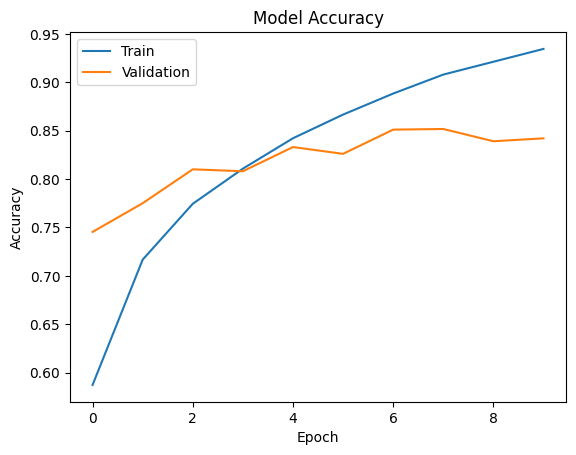

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train','Validation'])
plt.show()

Evaluate the model on the test set and report performance metrics:

○ Accuracy

○ Precision, Recall, F1-score per class

○ Confusion Matrix

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate predictions
val_generator.reset()
predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Report performance metrics
print(classification_report(y_true, y_pred, target_names=class_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 426ms/step
              precision    recall  f1-score   support

   buildings       0.85      0.76      0.80       437
      forest       0.95      0.96      0.95       474
     glacier       0.78      0.80      0.79       553
    mountain       0.74      0.82      0.78       525
         sea       0.85      0.77      0.81       510
      street       0.83      0.85      0.84       501

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



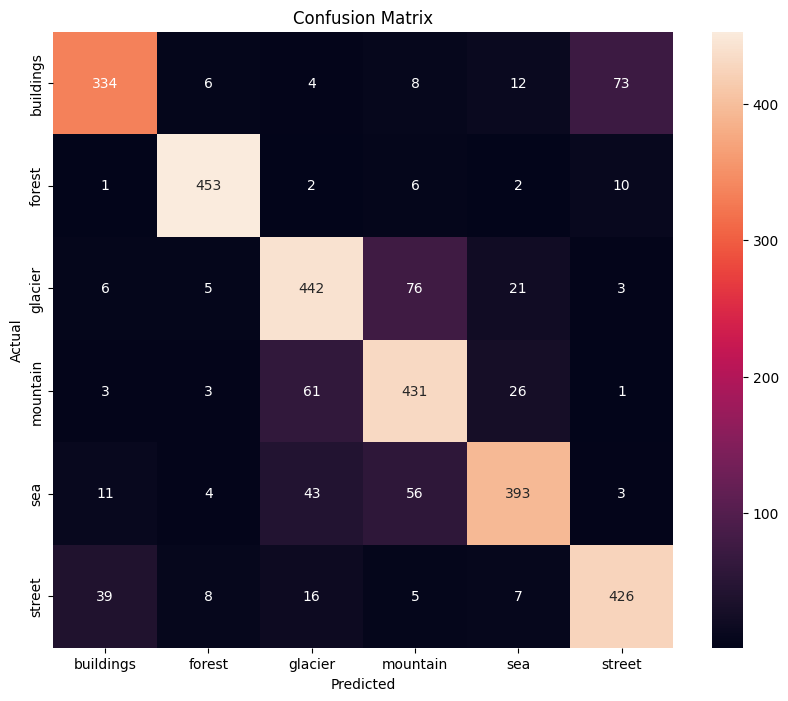

In [46]:
# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

TEST THE MODEL ON TEST DATASET

In [ ]:
test_loss, test_acc = model.evaluate(val_generator)

print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 447ms/step - accuracy: 0.8359 - loss: 0.6623
Test Accuracy: 0.8420000076293945


VISUAL TEST ON SINGLE IMAGE

In [ ]:
img_path = val_generator.filepaths[0]

img = image.load_img(img_path,target_size=(150,150))
img_array = image.img_to_array(img)

img_array = img_array/255.0
img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


CONVERT PREDECTION TO CLASS NAME

In [ ]:
class_indices = train_generator.class_indices
classes = list(class_indices.keys())

predicted_class = classes[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

Predicted Class: buildings


06. Visualize predictions for at least 10 random test images with predicted vs. actual labels.

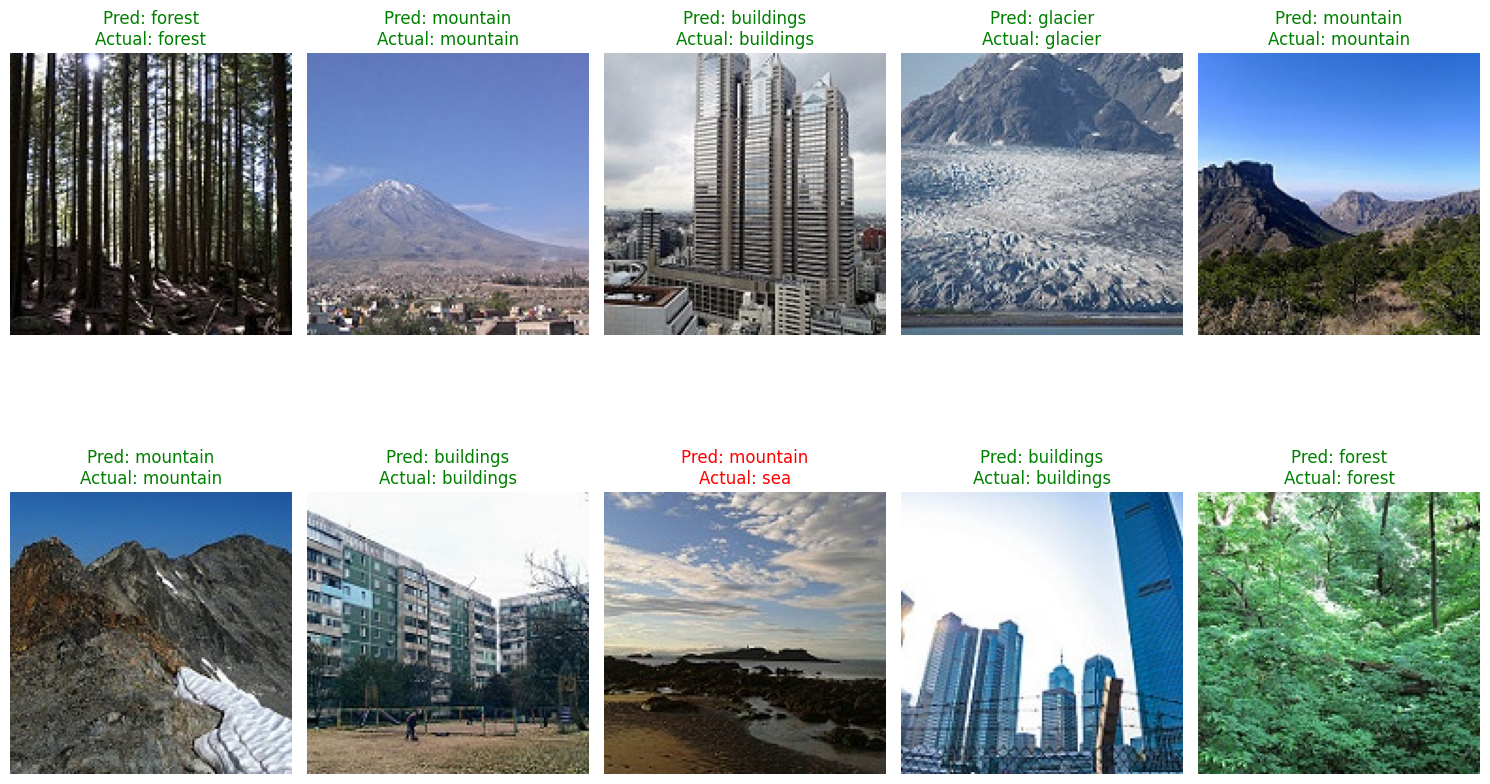

In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Visualize 10 random predictions
plt.figure(figsize=(15, 10))
for i in range(10):
    # Select a random index
    idx = np.random.randint(0, len(val_generator.filenames))

    # Load and preprocess image for display
    # Use val_generator.filepaths[idx] which contains the correct absolute path.
    img_path = val_generator.filepaths[idx]
    img = image.load_img(img_path, target_size=(150, 150))

    # Get model prediction
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred_prob = model.predict(img_array, verbose=0) # Suppress verbose output during prediction
    pred_label = class_labels[np.argmax(pred_prob)]
    actual_label = class_labels[y_true[idx]]

    # Plotting
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    color = 'green' if pred_label == actual_label else 'red'
    plt.title(f"Pred: {pred_label}\nActual: {actual_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

DISPLAY THE IMAGE VISUALLY

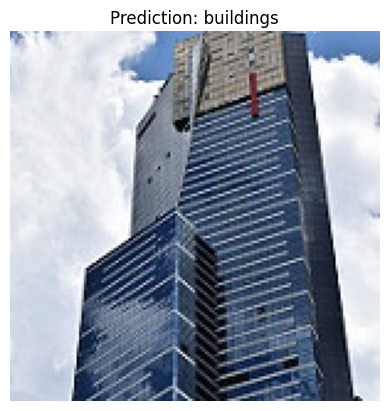

In [ ]:
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


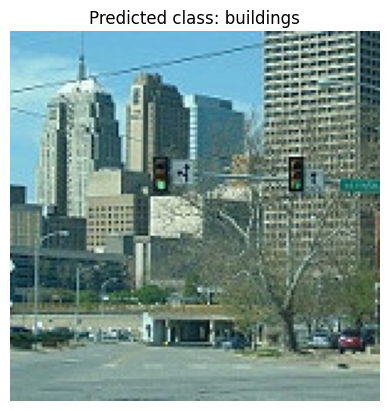

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Use a valid image path from the validation generator
# Using a different index (e.g., 1) to test a new image compared to the previous cell.
img_path = val_generator.filepaths[1]

# load image with the correct target size
img = image.load_img(img_path, target_size=(150,150))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# Convert prediction to class name
predicted_class_2 = classes[np.argmax(prediction)]

# show image
plt.imshow(img)
plt.title(f"Predicted class: {predicted_class_2}")
plt.axis("off")
plt.show()

In [ ]:
class_indices = train_generator.class_indices
classes = list(class_indices.keys())

predicted_class_2 = classes[np.argmax(prediction)]

print("Predicted Class:", predicted_class_2)

Predicted Class: buildings


○ Buildings

○ Forest

○ Glacier

○ Mountain

○ Sea

○ Street